# 1. CAMERA ENCODER (LSS)


## IMPORTING LIBRARES

In [1]:
import torch
from opencood.models.heter_encoders import LiftSplatShoot
import opencood.hypes_yaml.yaml_utils as yaml_utils
import os

## LOADING YAMLS CONFIGURATION

In [2]:


YAML_PATH = "opencood/hypes_yaml/opv2v/CameraOnly/camera_attfuse.yaml"
CKPT_PATH = "checkpoints/opv2v_camera/HeterBaseline_opv2v_camera_attfuse_2023_08_08_16_50_01/net_epoch_bestval_at17.pth"

assert os.path.exists(YAML_PATH), f"YAML IS NOT FOUND: {YAML_PATH}"
assert os.path.exists(CKPT_PATH), f"CHECKPOINT IS NOT FOUND: {CKPT_PATH}"

hypes = yaml_utils.load_yaml(YAML_PATH)

hypes["validate_dir"] = "dataset"
hypes["test_dir"] = "dataset"
print("YAML:", YAML_PATH) 
print("Checkpoint:", CKPT_PATH) 
print("Fusion dataset:", hypes["fusion"]["core_method"]) 
print("Model:", hypes["model"]["core_method"]) 
print("Test dir:", hypes["test_dir"]) 
print("img_features:", hypes["model"]["args"]["m2"]["encoder_args"]["img_features"]) 
print("ddiscr:", hypes["model"]["args"]["m2"]["encoder_args"]["grid_conf"]["ddiscr"]) 
print("score threshold:", hypes["postprocess"]["target_args"]["score_threshold"]) 
print("NMS threshold:", hypes["postprocess"]["nms_thresh"])

YAML: opencood/hypes_yaml/opv2v/CameraOnly/camera_attfuse.yaml
Checkpoint: checkpoints/opv2v_camera/HeterBaseline_opv2v_camera_attfuse_2023_08_08_16_50_01/net_epoch_bestval_at17.pth
Fusion dataset: intermediateheter
Model: heter_model_baseline
Test dir: dataset
img_features: 128
ddiscr: [2, 50, 48]
score threshold: 0.2
NMS threshold: 0.15


### COMMENTS ABOUT TYPE OF DATASET


Usually you have three dataset paths:

* `root_dir` = training data. Used when `train=True`.
* `validate_dir` = validation data. Used to check performance during training and, in this HEAL loader, also often when `train=False`.
* `test_dir` = final test/inference data. Used for final evaluation scripts depending on how that script is written.

Purpose:

```text
train set → learn weights
validation set → choose/tune model
test set → final unbiased evaluation
```

In your case, HEAL’s `build_dataset(..., train=False)` is reading `validate_dir`, which is why we pointed `validate_dir` to your local inference dataset.


### Inspectioning THE CONF OF THE MODALITY FOR ENCODER (CAMERA ONLY)


In [3]:
#print(hypes["model"]["args"].keys())
#print(hypes["model"]["args"]["m2"].keys())
encoder_args=hypes["model"]["args"]["m2"]["encoder_args"]
#print(encoder_args.keys())
for k, v in encoder_args.items():
    print(k, ":", v)

anchor_number : 2
grid_conf : {'xbound': [-51.2, 51.2, 0.4], 'ybound': [-51.2, 51.2, 0.4], 'zbound': [-10, 10, 20.0], 'ddiscr': [2, 50, 48], 'mode': 'LID'}
data_aug_conf : {'resize_lim': [0.65, 0.7], 'final_dim': [384, 512], 'rot_lim': [-3.6, 3.6], 'H': 600, 'W': 800, 'rand_flip': False, 'bot_pct_lim': [0.0, 0.05], 'cams': ['camera0', 'camera1', 'camera2', 'camera3'], 'Ncams': 4}
img_downsample : 8
img_features : 128
use_depth_gt : False
depth_supervision : True
camera_encoder : EfficientNet


## ENCODER INSTANTIATION

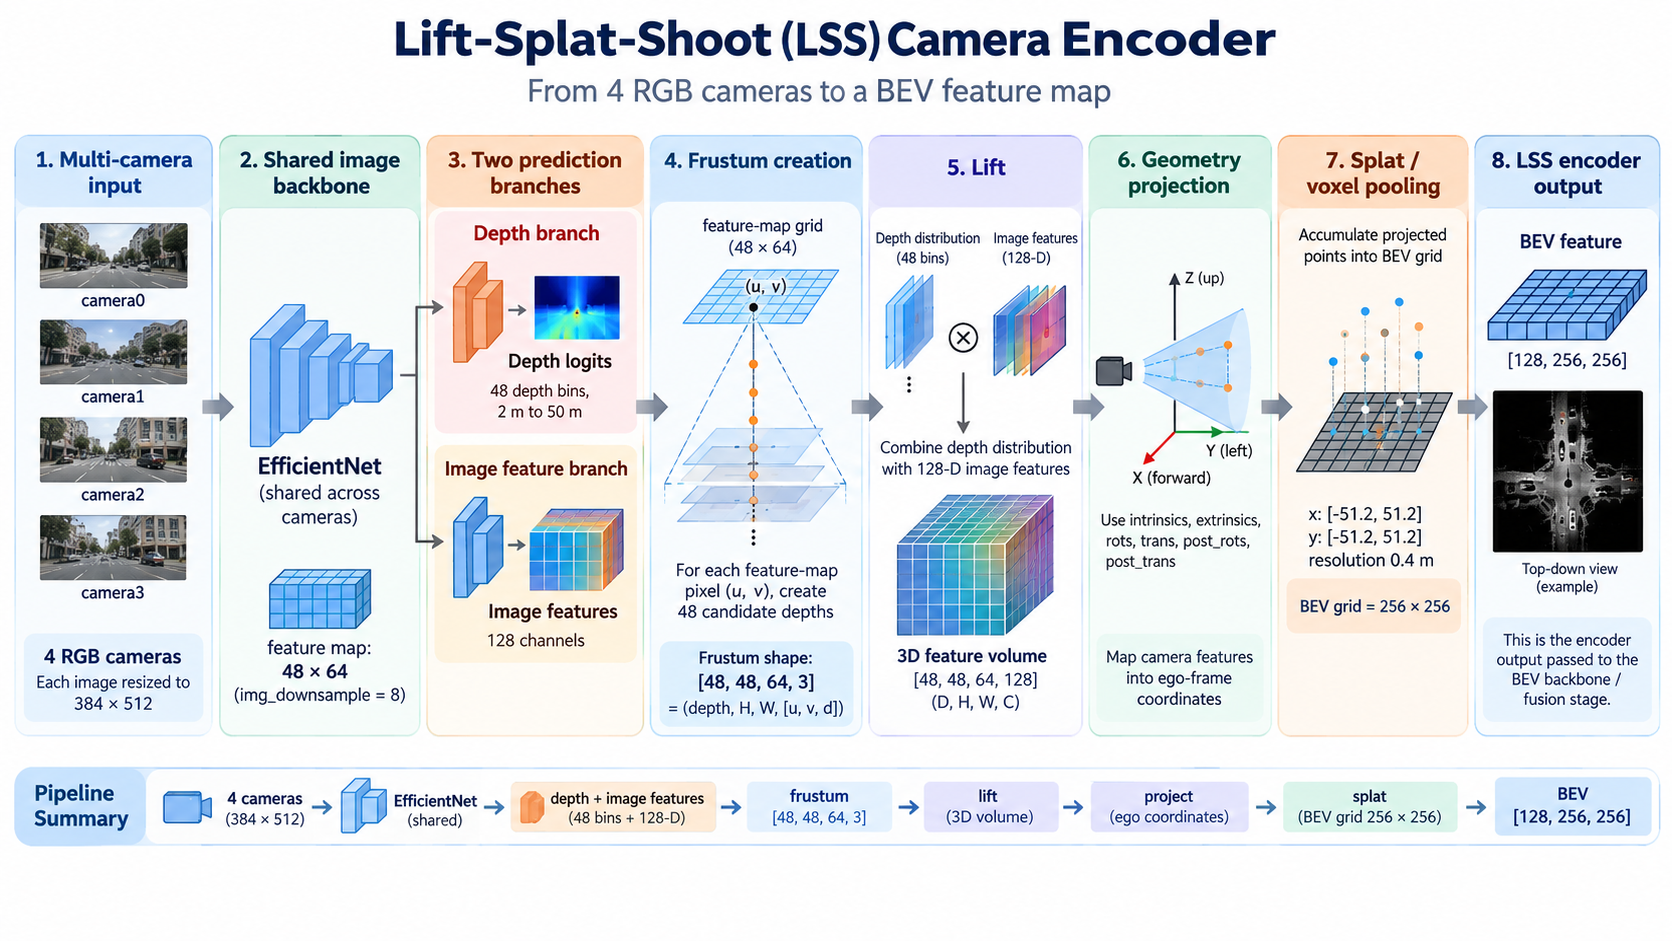
EfficientNet
→ image feature branch: 128-D feature at each (u,v)
→ depth branch: 48 probabilities at each (u,v)

Frustum
→ for that same (u,v), creates 48 possible 3D locations:
   (u,v,d1)...(u,v,d48)

###  Loading Encoder

In [4]:
encoder=LiftSplatShoot(encoder_args)

ckpt = torch.load(CKPT_PATH, map_location="cpu")
state = ckpt.get("model_state_dict", ckpt)

encoder_state = {
    k.replace("encoder_m2.", "", 1): v
    for k, v in state.items()
    if k.startswith("encoder_m2.")
}

#print("Found:", len(encoder_state), "encoder tensors")
#print(encoder)
encoder.load_state_dict(encoder_state, strict=True)
encoder.eval()

Loaded pretrained weights for efficientnet-b0


LiftSplatShoot(
  (camencode): CamEncode(
    (trunk): EfficientNet(
      (_conv_stem): Conv2dStaticSamePadding(
        3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_blocks): ModuleList(
        (0): MBConvBlock(
          (_depthwise_conv): Conv2dStaticSamePadding(
            32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
            (static_padding): ZeroPad2d((1, 1, 1, 1))
          )
          (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
          (_se_reduce): Conv2dStaticSamePadding(
            32, 8, kernel_size=(1, 1), stride=(1, 1)
            (static_padding): Identity()
          )
          (_se_expand): Conv2dStaticSamePadding(
            8, 32, kernel_size=(1, 1), stride=(1, 1)
            (static_padding): Id

## CREATING DATA SET

In [5]:
from opencood.data_utils.datasets import build_dataset
#----------------------------------------------------------------------------------
#Handling logs  for specifing which car modalities
hypes["heter"]["assignment_path"]='opencood/logs/heter_modality_assign/opv2v_4modality.json'
hypes["input_source"] = ["camera"] # no depth camera
hypes["model"]["args"]["m2"]["encoder_args"]["depth_supervision"] = False # no need for GT
#-------------------------------------------------------------------------------
encoder.depth_supervision = False  #no depth suversion 
encoder.camencode.depth_supervision = False
#-----------------Building dataset object-------------------------------------------
dataset=build_dataset(hypes,visualize=False,train=False)
#----------------------Sampling data-----------------------------------------------------------
sample=dataset[0]
ego = sample["ego"]
print(f"Dataset Length:{len(dataset)}") 
#print(sample.keys())
#print(ego.keys())
print(type(ego["input_m2"]))
print(ego["input_m2"].keys())
#------------tests----------------
#print(hypes["postprocess"])
#print(hypes["heter"]["assignment_path"]) 
#print(hopes["postprocess"])
#print(hypes.get("input_source"))
#print(hypes.get("add_data_extension"))
#-----------printing dimension auxiliar matrices-----------------
for k,v in ego ["input_m2"].items():
    print(k,v.shape)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Dataset dir: dataset
len: 98
len: 98
Dataset Length:98
<class 'collections.OrderedDict'>
odict_keys(['imgs', 'intrins', 'extrinsics', 'rots', 'trans', 'post_rots', 'post_trans'])
imgs torch.Size([3, 4, 3, 384, 512])
intrins torch.Size([3, 4, 3, 3])
extrinsics torch.Size([3, 4, 4, 4])
rots torch.Size([3, 4, 3, 3])
trans torch.Size([3, 4, 3])
post_rots torch.Size([3, 4, 3, 3])
post_trans torch.Size([3, 4, 3])


## DEBUGGIN FOR ONE CAR 

In [6]:
input_m2 = ego["input_m2"]

one_cav = {k: v[0:1] for k, v in input_m2.items()}

for k, v in one_cav.items():
    print(k, v.shape)

imgs torch.Size([1, 4, 3, 384, 512])
intrins torch.Size([1, 4, 3, 3])
extrinsics torch.Size([1, 4, 4, 4])
rots torch.Size([1, 4, 3, 3])
trans torch.Size([1, 4, 3])
post_rots torch.Size([1, 4, 3, 3])
post_trans torch.Size([1, 4, 3])


## MAKE SURE ENCORDER WEIGHTS AND FRUSTRUM ARE IN GPU  

In [7]:
encoder = encoder.to("cuda")
device = next(encoder.parameters()).device
print(device)
print(encoder.frustum.device)

cuda:0
cuda:0


### Explanation Frustrum  

Imagine one camera pixel looking at a car in front of you.

Suppose the feature-map location is:

```text
row 20, column 30
```

That location corresponds to one direction/ray leaving the camera.

Now HEAL asks:

```text
What if the object along this ray is 2 m away?
What if it is 3 m away?
What if it is 5 m away?
...
What if it is 50 m away?
```

Those are the 48 depth bins.

So:

```python
frustum[10, 20, 30]
```

means:

```text
take row 20
take column 30
take the 11th candidate distance
```

If depth bin 10 corresponds to, say, `7.4 m`, then:

```text
frustum[10,20,30] = [u_coordinate, v_coordinate, 7.4]
```

Tangible picture:

```text
camera pixel/ray
   \
    \  2m   candidate point
     \ 4m   candidate point
      \ 7m  candidate point
       \ 12m candidate point
        \ ...
         \ 50m candidate point
```

So the first index is not a physical coordinate. It is just: **which one of the 48 possible distances along that same camera ray are we talking about?**


Yes. You choose:

```text
depth-bin index = 10
feature row = 20
feature col = 30
```

Then `frustum[10,20,30]` stores:

```text
[u, v, depth]
```

where `u` and `v` are the corresponding coordinates in the original/preprocessed image plane:

* `u` = horizontal pixel coordinate
* `v` = vertical pixel coordinate

So `20,30` are indices on the **48×64 feature map**, while `u,v` are their mapped positions on the **384×512 image**.

And `10` is just “pick depth hypothesis #10,” whose actual distance might be, say, 7.4 m.


## MOVING CAMERA CAR TENSORS TO GPU 



In [8]:
one_cav = {
    k: v.to(device) if torch.is_tensor(v) else v
    for k, v in one_cav.items()
}

### Explanation 

You are moving every tensor inside `one_cav` to the same device as the model, usually GPU.

So:

```text
imgs, intrins, rots, trans, post_rots, post_trans
CPU → CUDA
```

The `if torch.is_tensor(v)` part means: only call `.to(device)` on tensor values; leave anything else unchanged.

Few words : This line of code moves all PyTorch tensors within the one_cav dictionary to a specific hardware device (like a GPU or CPU) while leaving non-tensor values untouched.

## ONE CAR THROUGH ENCODER



In [9]:
input_dict ={
    "inputs_m2": one_cav
}
with torch.no_grad():
    bev=encoder(input_dict,"m2")
print(bev.shape)

torch.Size([1, 128, 256, 256])


### Explanation 

Here:

```python
input_dict = {"inputs_m2": one_cav}
```

you wrap your one-car camera tensors in the exact dictionary key that `LiftSplatShoot.forward()` expects.

Then:

```python
with torch.no_grad():
```

turns off gradient calculation because you are doing inference, not training.

Then:

```python
bev = encoder(input_dict, "m2")
```

runs the full camera encoder for modality `m2`:

```text
4 camera images
→ EfficientNet
→ depth/image heads
→ lift
→ geometry
→ voxel pooling
→ BEV
```

And:

```python
print(bev.shape)
```

shows the output shape, which you got as:

```text
[1, 128, 256, 256]
```

So that line is the actual moment where your QCar/OPV2V camera data becomes a BEV feature.

## SUMMARY 

### Explanation 




At the end of **LSS**, the network already knows much more than just “pixels → BEV.”

It has learned:

```text
RGB image
→ visual features from EfficientNet
→ estimated depth distribution for each image location
→ lifted those image features into 3D
→ splatted/projected them into BEV
```

So the LSS output:

```text
[1,128,256,256]
```

is already a **semantic BEV feature map**.

But it is still relatively low-level/local.

The **BEV backbone** then learns:

```text
which BEV patterns matter for object detection
→ local shapes
→ larger vehicle/context patterns
→ multi-scale structure
```

So roughly:

```text
LSS = understand images + geometry → BEV representation
BEV backbone = understand useful spatial patterns inside that BEV




# 2. BEV BackBone + Shrinker

## Instantiate the `m2` backbone from YAML

In [10]:
from opencood.models.sub_modules.base_bev_backbone import BaseBEVBackbone
backbone_args=hypes["model"]["args"]["m2"]["backbone_args"]
backbone=BaseBEVBackbone(backbone_args,128).to("cuda")
backbone.eval()                                            

BaseBEVBackbone(
  (blocks): ModuleList(
    (0): Sequential(
      (0): ZeroPad2d((1, 1, 1, 1))
      (1): Conv2d(128, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (2): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (5): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (8): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (9): ReLU()
      (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (11): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (12): ReLU()
    )
    (1): Sequential(
      (0): ZeroPad2d((1, 1, 1, 1))
      (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2,

###  Explanation 

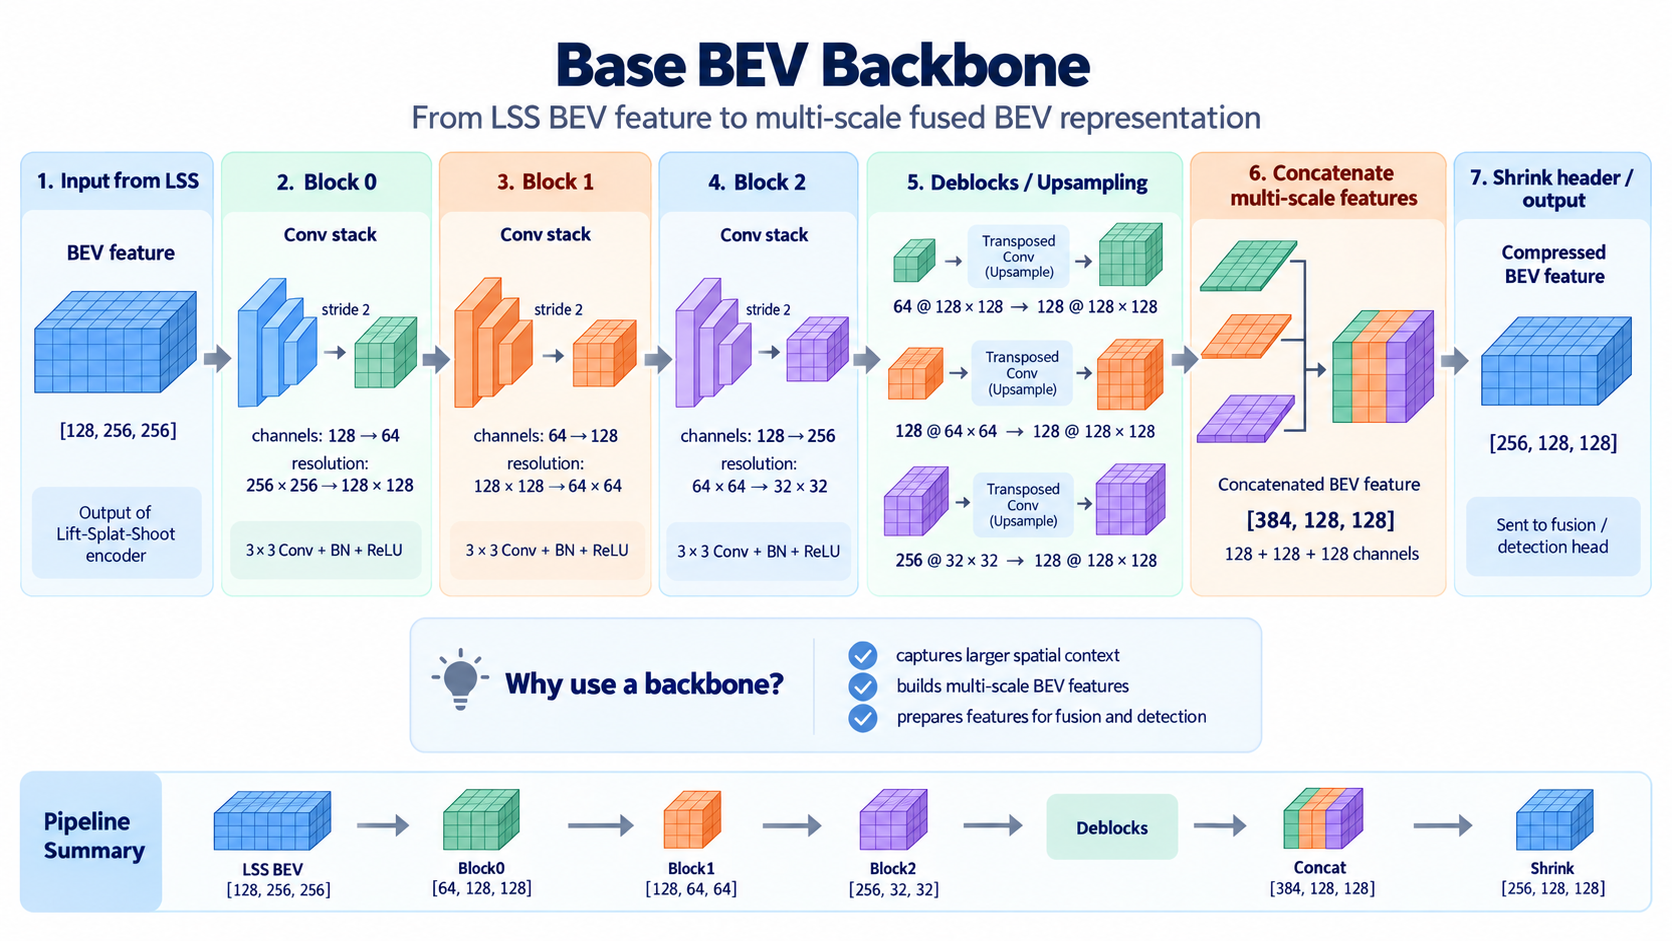

Block 0 filters learn small/local BEV patterns. **fine details** +  

Block 1 filters learn medium-size combinations of those patterns. **medium context** + 

Block 2 filters learn larger/global structures and context. **large context**

AT THE  END OF THE BLOCK 2 OF 256 CHANNELS 

Some channels may respond to vehicle-like structure, others edges, orientation, context, etc.

less spatial detail
→ more feature channels
→ more abstract patterns can be represented


Why 128? Because your LSS output is:

[1, 128, 256, 256]

so the backbone receives 128 input channels.



Do only this first and show me if it creates successfully.

LSS → **backbone** → **shrinker** → fusion → heads

This line:

backbone = BaseBEVBackbone(backbone_args, 128).to("cuda")

does 3 things:

BaseBEVBackbone(...) → creates the BEV backbone architecture
backbone_args        → loads its layer settings from the YAML
128                  → says the input BEV has 128 channels
.to("cuda")          → moves the backbone to the GPU

Through the three convolutional blocks.

Starting from the LSS BEV:

[128, 256, 256]

Block 0 looks at small neighboring BEV cells, so it learns local patterns like edges, compact shapes, and nearby spatial structure.

Block 1 downsamples again, so each feature now “sees” a larger area of the BEV. It can capture medium-scale structures, like larger parts of vehicles and their surroundings.

Block 2 downsamples again, so each feature has an even larger receptive field. That gives broader scene/context information.

Then the deblocks bring all three scales back to the same spatial size and concatenate them:

fine details
+ medium context
+ coarse/global context
→ richer BEV representation

So the backbone learns useful detection features by repeatedly applying convolutions while increasing the area of the BEV each feature can “see.”

## RUN BEV through the backbone

In [11]:
data_dict = {
    "spatial_features": bev
}

with torch.no_grad():
    backbone_out = backbone(data_dict)

print(backbone_out.keys())
print(backbone_out["spatial_features_2d"].shape)

dict_keys(['spatial_features', 'spatial_features_2d'])
torch.Size([1, 384, 128, 128])


## RUN SHRINKER 

### Instatiate the shrinker 

In [12]:
from opencood.models.sub_modules.downsample_conv import DownsampleConv
shrink_args=hypes["model"]["args"]["m2"]["shrink_header"]
shrinker=DownsampleConv(shrink_args).to("cuda")
shrinker.eval()

DownsampleConv(
  (layers): ModuleList(
    (0): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
  )
)

### Running the shrinker

In [13]:
with torch.no_grad():
    intermediate=shrinker(backbone_out["spatial_features_2d"])
print(intermediate.shape)

torch.Size([1, 256, 128, 128])


# 3. Fusion (Att_fussion)

## Inspectionating the METHOD

In [14]:
print(hypes["model"]["args"]["fusion_method"])
print(hypes["model"]["args"]["att"])

att
{'feat_dim': 256}


## Instantiate the Fusion method

In [15]:
from opencood.models.fuse_modules.fusion_in_one import AttFusion
fusion_net=AttFusion(256).to("cuda")
fusion_net.eval()

AttFusion(
  (att): ScaledDotProductAttention()
)

In [16]:
import inspect 
print(inspect.signature(fusion_net.forward))

(xx, record_len, affine_matrix)


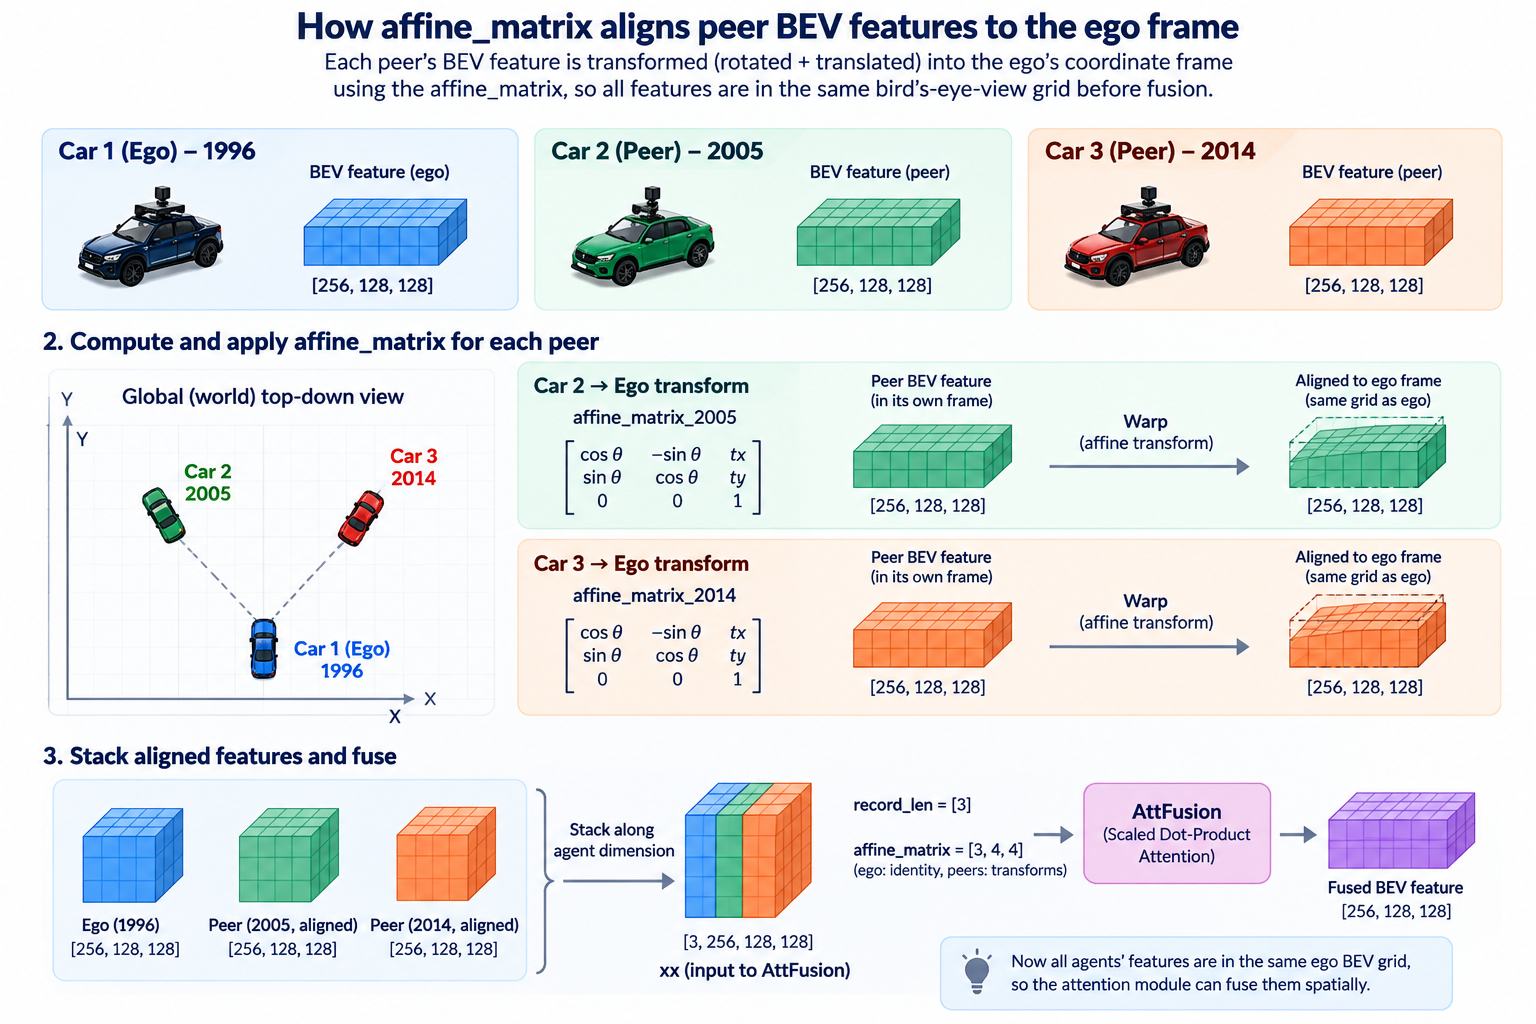

An **affine matrix** tells HEAL how to move a peer car’s BEV feature into the ego car’s coordinate frame.

It encodes mainly:

```text
rotation + translation
```

Example:

```text
peer is 3 m to the right
and rotated 20°
```

The affine matrix says:

```text
rotate peer BEV by 20°
shift it by the relative x/y distance
```

After that, the peer feature lines up with the ego BEV, so the same real-world object appears in the same BEV location before fusion.


In [17]:
torch.save(intermediate.detach().cpu(), "peer_feature.pt")

In [18]:
torch.save(
    ego["input_m2"]["imgs"][0].cpu(),
    "dataset0_cav0_4cams.pt"
)